In [1]:
%matplotlib inline

In [2]:
import matplotlib
import pysmurf.client
import matplotlib.pylab as plt
import numpy as np
import sys
import os
epics_prefix="smurf_server_s3"
config_file=os.path.abspath("/usr/local/src/pysmurf/cfg_files/slab/experiment_slab_rfsoc_extref.cfg")
S = pysmurf.client.SmurfControl(epics_root=epics_prefix,cfg_file=config_file,setup=False,make_logfile=False,shelf_manager="shm-smrf-sp01")

[ 2026-03-24 17:37:56 ]  ERROR : band 0 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-03-24 17:37:56 ]  ERROR : band 1 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-03-24 17:37:56 ]  ERROR : band 2 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-03-24 17:37:56 ]  ERROR : band 3 is present in pysmurf cfg file, but its bay is not enabled!


In [3]:
plt.ion()

# Setup

Only once per power on ; configure hardware

In [4]:
S.setup()

[ 2026-03-24 17:38:23 ]  System already configured once while this Rogue server has been up.
[ 2026-03-24 17:38:23 ]  If you really want to configure again, run setup with force_configure=True.


False

We're going to take I,Q data.  This is not standard data-taking, so have to set some flags to enable it.  Currently, this data mode is only supported for one bay at a time.  So we have to select I/Q data mode, and tell it which bay to give us data from.  The "bay" concept is only meaningful in the original SMuRF ATCA hardware context; for the RFSoC bay 0 just means bands 0,1,2,3 and bay 1 means bands 4,5,6,7.

In [5]:
S._caput(f'{S.app_core}baySelStream', 0, write_log=True) # going to be streaming I/Q for bay 0 only.
S._caput(f'{S.app_core}modeStream', 1,write_log=True) # =1 means to stream I/Q data, which is a nonstandard mode.

[ 2026-03-24 17:38:39 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:baySelStream 0
[ 2026-03-24 17:38:39 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:modeStream 1


Which band are we working in?

In [6]:
band=0

This register truncates IQ data in streaming mode.  Set to 7 to eliminate truncation.

In [7]:
S.set_lms_gain(band,7)

## Taking streaming data

The RFSoC thinks it's a SMuRF system.  Disabuse it of this notion.

In [8]:
S.set_band_center_mhz(band,750)

Set some tones to stream IQ data for.

In [10]:
S.all_off()
S.set_fixed_tone(511.101,12)
S.set_fixed_tone(575.292,12)
S.set_fixed_tone(636.383,12)
S.set_fixed_tone(694.474,12)
S.set_fixed_tone(728.565,12)
S.set_fixed_tone(755.656,12)
S.set_fixed_tone(812.747,12)
S.set_fixed_tone(879.838,12)
S.set_fixed_tone(931.929,12)
S.set_fixed_tone(989.010,12)

[ 2026-03-24 17:39:08 ]  Turning off tones
[ 2026-03-24 17:39:17 ]  Turning off flux ramp
[ 2026-03-24 17:39:17 ]  Turning off all TES biases


(0, 454)

What's on?

In [11]:
S.which_on(band)

array([ 50,  88, 108, 151, 237, 239, 267, 313, 320, 454])

What does the raw ADC data look like?

[ 2026-03-24 17:39:31 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 524288
[ 2026-03-24 17:39:32 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 0


/usr/local/src/pysmurf/python/pysmurf/client/util/smurf_util.py:1770: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(plot_fn)


[ 2026-03-24 17:39:33 ]  ADC plot saved to /data/smurf_data/20260324/1774373876/plots/1774373972_adc0.png
[ 2026-03-24 17:39:33 ]  Saving raw adc data to /data/smurf_data/20260324/1774373876/outputs/1774373972_adc0


/usr/local/lib/python3.8/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


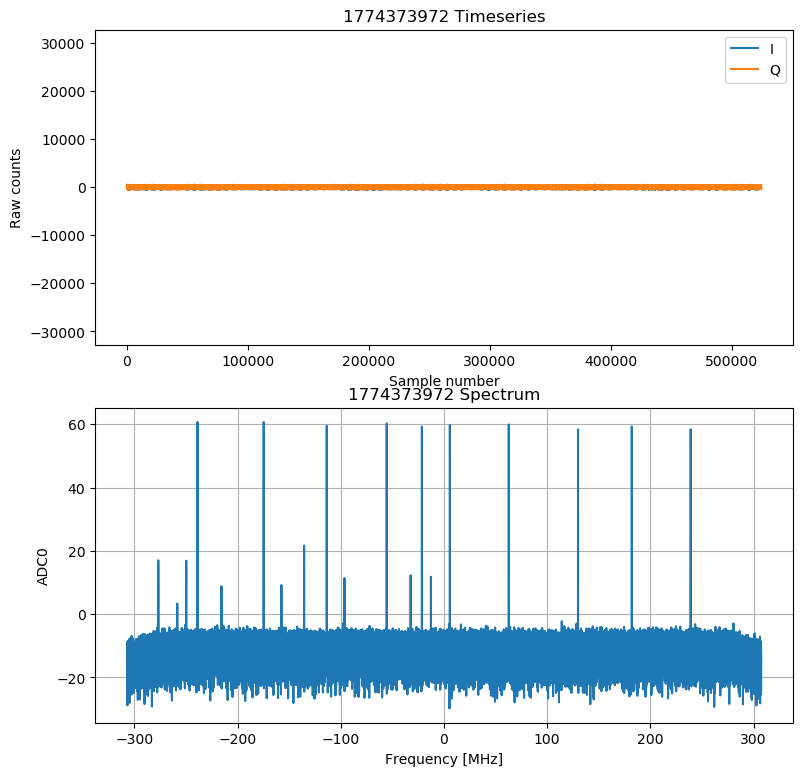

In [12]:
adc=S.read_adc_data(band,make_plot=True,show_plot=True)

Good, there's 10 tones.

Let's stream some data.  Start off with streaming off, and try for 37 kHz (probably the fastest we can go until Jenny finished on-going speed up project).  Currently, we're tricking the SMuRF firmware into sampling at 37 kHz by setting the flux ramp to that, even though there is no flux ramp.  That just gets sample triggering running.

In [13]:
S.stream_data_off()
S.flux_ramp_setup(37.5,0)

[ 2026-03-24 17:41:30 ]  caput smurf_server_s3:AMCc:SmurfProcessor:FileWriter:Close 1
[ 2026-03-24 17:41:30 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:enableStreaming 0
[ 2026-03-24 17:41:30 ]  Waiting 0.15 seconds after...
[ 2026-03-24 17:41:30 ]  Done waiting.
[ 2026-03-24 17:41:30 ]  Percent full scale = 0.000%


Want to stream with no filter, and with no downsampling, because we are insane

In [14]:
S.set_filter_disable(False)
S.set_downsample_factor(1)

print(f'S.get_sample_frequency()={S.get_sample_frequency()}')
print(f'S.get_downsample_factor()={S.get_downsample_factor()}')
print(f'S.get_filter_disable()={S.get_filter_disable()}')

S.get_sample_frequency()=37500.0
S.get_downsample_factor()=1
S.get_filter_disable()=0


Let's set the filter

In [15]:
import scipy.signal as signal
# I think this configures for a 12 kHz roll-off.
b, a = signal.butter(4, 12.0 / 37.5)
S.set_filter_a(a)
S.set_filter_b(b)

Lost frames is a concern at high rate, so we'll check frame and frame loss counts before and after taking data.

In [25]:
cnt0=S.get_frame_count()
losscnt0=S.get_frame_loss_cnt()

# Here IQ_mode tells the data-taking and read-back that we're taking data in the nonstandard I/Q mode.
data_file=S.take_stream_data(10,IQ_mode=True)

cnt1=S.get_frame_count()
losscnt1=S.get_frame_loss_cnt()

[ 2026-03-24 18:20:26 ]  Starting to take data.
[ 2026-03-24 18:20:26 ]  Input downsample factor is None. Using value already in pyrogue: 1
[ 2026-03-24 18:20:26 ]  CryoCard.do_read failed, retry 1 / 5.
[ 2026-03-24 18:20:26 ]  CryoCard.do_read failed, retry 2 / 5.
[ 2026-03-24 18:20:26 ]  CryoCard.do_read failed, retry 3 / 5.
[ 2026-03-24 18:20:26 ]  CryoCard.do_read failed, retry 4 / 5.
[ 2026-03-24 18:20:26 ]  CryoCard.do_read failed, retry 5 / 5.
[ 2026-03-24 18:20:26 ]  flux_ramp_ac_dc_relay status: Failed to read from cryo card.
[ 2026-03-24 18:20:26 ]  flux_ramp_ac_dc_relay_status = None - NOT A VALID STATE.
[ 2026-03-24 18:20:28 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Unwrapper:reset 1
[ 2026-03-24 18:20:28 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Filter:reset 1
[ 2026-03-24 18:20:29 ]  Writing to file : /data/smurf_data/20260324/1774373876/outputs/1774376429.dat
[ 2026-03-24 18:20:29 ]  /data/smurf_data/20260324/1774373876/outputs/1774376429_mask.txt
[ 2026-03-24 18:2

Did we get the number of frames we were expecting, and where there any lost frames?

In [26]:
print(f'Number of frames = {cnt1-cnt0}')
print(f'Number of frames lost = {losscnt1-losscnt0}')

Number of frames = 329248
Number of frames lost = 0


In [27]:
print(f'Expected {10./(1./(1.e3*S.get_flux_ramp_freq()))} frames')

Expected 375000.0 frames


Close, but may want to pull it back a little.  Didn't register any dropped frames, but at these higher rates there be counters we don't usually check which we should worry about.

In [28]:
filesize_MB = os.path.getsize(data_file)/1024**2
print(f'file size: {filesize_MB} MB')

file size: 60.47240734100342 MB


In [29]:
t,d,m,h=S.read_stream_data(data_file,return_header=True)

[ 2026-03-24 18:20:39 ]  Reading /data/smurf_data/20260324/1774373876/outputs/1774376429.dat
Processing data records from /data/smurf_data/20260324/1774373876/outputs/1774376429.dat
[ 2026-03-24 18:20:40 ]  2048 elements loaded
(0, 16) (2048, 16)
[ 2026-03-24 18:20:41 ]  4096 elements loaded
(2048, 16) (2048, 16)
[ 2026-03-24 18:20:42 ]  6144 elements loaded
(4096, 16) (2048, 16)
[ 2026-03-24 18:20:42 ]  8192 elements loaded
(6144, 16) (2048, 16)
[ 2026-03-24 18:20:43 ]  10240 elements loaded
(8192, 16) (2048, 16)
[ 2026-03-24 18:20:44 ]  12288 elements loaded
(10240, 16) (2048, 16)
[ 2026-03-24 18:20:45 ]  14336 elements loaded
(12288, 16) (2048, 16)
[ 2026-03-24 18:20:46 ]  16384 elements loaded
(14336, 16) (2048, 16)
[ 2026-03-24 18:20:46 ]  18432 elements loaded
(16384, 16) (2048, 16)
[ 2026-03-24 18:20:47 ]  20480 elements loaded
(18432, 16) (2048, 16)
[ 2026-03-24 18:20:48 ]  22528 elements loaded
(20480, 16) (2048, 16)
[ 2026-03-24 18:20:49 ]  24576 elements loaded
(22528, 16) (

FYI it's not demo'd here, but there are modes which support distributing the data across multiple files, and there exist much faster tools for reading in the data.

Samples are accumulated over the flux ramp frame.  To get original data, must divide by the accumulation factor.  That factor is 

In [30]:
S.get_channel_frequency_mhz(band)

2.4

In [31]:
accum_factor=(1.e6*S.get_channel_frequency_mhz(band))/(S.get_flux_ramp_freq()*1.e3)
bit_factor=2**(12-S.get_lms_gain(band))*2**(7) # this 

print(f'bit_factor = {bit_factor}')
print(f'accum_factor = {accum_factor}')

bit_factor = 4096
accum_factor = 64.0


Kind of weird that that's not an integer ; may want to choose the flux ramp frequency more judiciously in future attempts.

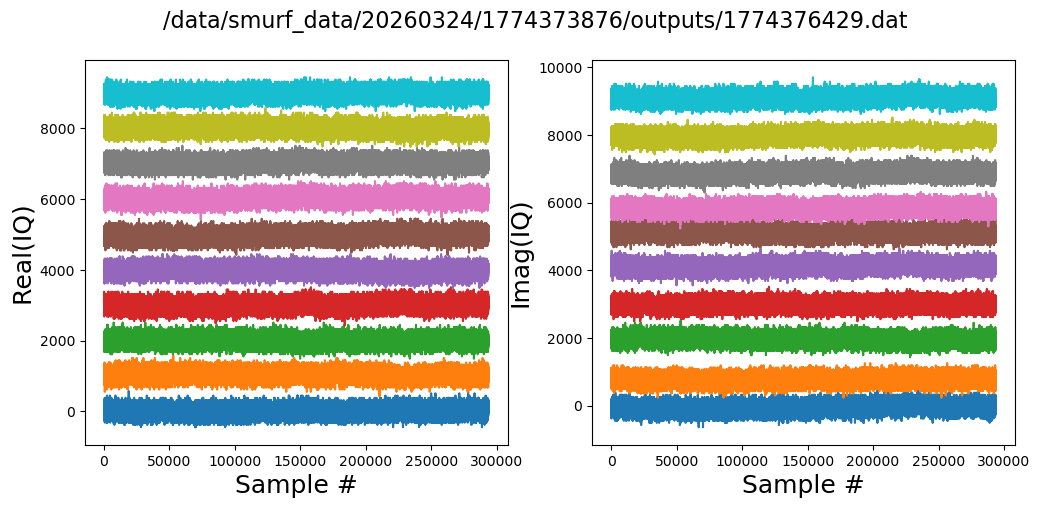

In [32]:
yoffset=1000
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ch in range(len(S.which_on(band))):
    ych=bit_factor*d[ch]/accum_factor
    ymax=np.max(ych)
    ymin=np.min(ych)
    yspan=ymax-ymin
    ymedian=np.median(ych)
    ax1.plot(np.real(ych-ymedian) + yoffset*ch)
    ax1.set_ylabel('Real(IQ)',fontsize=18)
    ax1.set_xlabel('Sample #',fontsize=18)
    ax2.plot(np.imag(ych-ymedian) + yoffset*ch)
    ax2.set_ylabel('Imag(IQ)',fontsize=18)
    ax2.set_xlabel('Sample #',fontsize=18)
    fig.suptitle(data_file,fontsize=16)
    #ax2.plot(np.real(ych-ymedian) + yoffset*ch)

How do PSDs look?

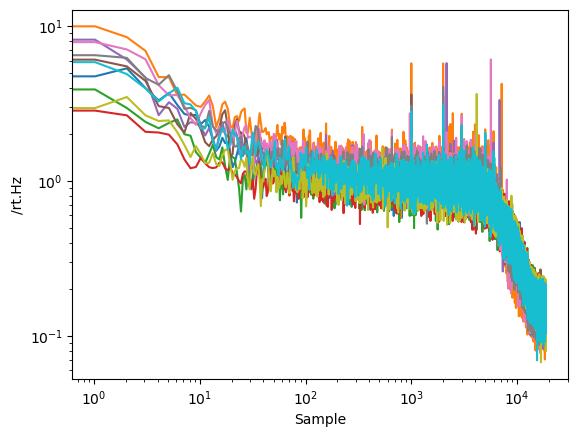

In [33]:
for ch in range(len(S.which_on(band))):
    ych=bit_factor*d[ch]/accum_factor
    ymax=np.max(ych)
    ymin=np.min(ych)
    yspan=ymax-ymin
    ymedian=np.median(ych)

    freq, pxx = signal.welch(np.abs(ych-ymedian), nperseg=len(ych)/8, fs=37.5e3)
    plt.loglog(freq, np.sqrt(pxx))
    plt.xlabel('Sample')
    plt.ylabel('/rt.Hz')